In [70]:
import time
from pathlib import Path

import cv2
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ResNet-18

In [71]:
import torchvision.models as models

In [72]:
class ResNet18Encoder(nn.Module):
    def __init__(self, in_channels=1, pretrained=False):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)

        # Replace first conv for grayscale input
        old_conv = backbone.conv1
        backbone.conv1 = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        # If using pretrained weights, initialize 1-channel conv sensibly
        if pretrained:
            with torch.no_grad():
                backbone.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))  # [B, 64, H/2,  W/2]
        x1 = self.maxpool(x0)                    # [B, 64, H/4,  W/4]
        x1 = self.layer1(x1)                    # [B, 64, H/4,  W/4]
        x2 = self.layer2(x1)                    # [B,128, H/8,  W/8]
        x3 = self.layer3(x2)                    # [B,256, H/16, W/16]
        x4 = self.layer4(x3)                    # [B,512, H/32, W/32]
        return x0, x1, x2, x3, x4

In [73]:
class ResNet18Heatmap(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.encoder = ResNet18Encoder(in_channels=1, pretrained=pretrained)

        self.up4 = self._up_block(512, 256)
        self.up3 = self._up_block(256 + 256, 128)
        self.up2 = self._up_block(128 + 128, 64)
        self.up1 = self._up_block(64 + 64, 64)

        self.head = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, kernel_size=1),   # interior + edge logits
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_hw = x.shape[-2:]
        x0, x1, x2, x3, x4 = self.encoder(x)

        y = F.interpolate(x4, size=x3.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up4(y)

        y = torch.cat([y, x3], dim=1)
        y = F.interpolate(y, size=x2.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up3(y)

        y = torch.cat([y, x2], dim=1)
        y = F.interpolate(y, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up2(y)

        y = torch.cat([y, x1], dim=1)
        y = F.interpolate(y, size=x0.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up1(y)

        y = torch.cat([y, x0], dim=1)
        y = self.head(y)

        y = F.interpolate(y, size=input_hw, mode="bilinear", align_corners=False)
        return y

# Instantiate model

In [74]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Heatmap(pretrained=True).to(DEVICE)

print(f"Model on device: {DEVICE}")
print(model)

Model on device: cuda
ResNet18Heatmap(
  (encoder): ResNet18Encoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-0

# Training setup

In [75]:
def total_variation_loss(x):
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy

def total_variation_loss(x):
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def compute_segmentation_loss(
    logits,
    target,
    interior_weight=1.0,
    edge_weight=2.0,
    lambda_tv=2e-5,
):
    pixel_loss = criterion(logits, target)  # [B,2,H,W]
    ch_w = torch.tensor(
        [interior_weight, edge_weight],
        device=logits.device,
        dtype=logits.dtype
    ).view(1, 2, 1, 1)

    bce_loss = (pixel_loss * ch_w).mean()

    probs = torch.sigmoid(logits)
    tv_loss = total_variation_loss(probs)

    loss = bce_loss + lambda_tv * tv_loss
    return loss, bce_loss.detach(), tv_loss.detach()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for batch_idx, (images, targets, _gt_instances) in enumerate(dataloader):
        images = images.to(device)    # [B,1,H,W]
        targets = targets.to(device)  # [B,2,H,W]

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Batch {batch_idx + 1}: "
                f"total={loss.item():.4f}, "
                f"bce={bce_l.item():.4f}, "
                f"tv={tv_l.item():.4f}"
            )

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }


@torch.no_grad()
def validate_one_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for images, targets, _gt_instances in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)

        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }

In [76]:
def calculate_seg_score(pred_masks, gt_seg_masks):
    ious = []
    for p_mask, g_mask in zip(pred_masks, gt_seg_masks):
        g_ids = np.unique(g_mask[g_mask > 0])
        p_ids = np.unique(p_mask[p_mask > 0])

        if len(g_ids) == 0:
            continue

        for gid in g_ids:
            target = (g_mask == gid)
            best_iou = 0
            # Find the overlapping predicted object
            overlapping_p_ids = np.unique(p_mask[target])
            for pid in overlapping_p_ids:
                if pid == 0:
                    continue
                pred = (p_mask == pid)
                inter = np.logical_and(target, pred).sum()
                union = np.logical_or(target, pred).sum()
                iou = inter / union
                if iou > 0.5:  # CTC requirement for a match
                    best_iou = iou
                    break
            ious.append(best_iou)

    return np.mean(ious) if ious else 0.0

In [77]:
def probs_to_instance_mask(interior_prob, threshold=0.5, min_area=10):
    binary = (interior_prob > threshold).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    out = np.zeros_like(labels, dtype=np.int32)
    next_id = 1

    for lab in range(1, num_labels):
        area = stats[lab, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        out[labels == lab] = next_id
        next_id += 1

    return out

In [78]:
@torch.no_grad()
def validate_seg_score(model, dataloader, device, threshold=0.5, min_area=10):
    model.eval()

    pred_masks = []
    gt_masks = []

    for images, _targets, gt_instances in dataloader:
        images = images.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits).detach().cpu().numpy()   # [B,2,H,W]
        gt_instances = gt_instances.numpy()                    # [B,H,W]

        for prob_map, gt_mask in zip(probs, gt_instances):
            interior_prob = prob_map[0]  # channel 0 = interior
            pred_inst = probs_to_instance_mask(
                interior_prob,
                threshold=threshold,
                min_area=min_area,
            )
            pred_masks.append(pred_inst)
            gt_masks.append(gt_mask.astype(np.int32))

    seg = calculate_seg_score(pred_masks, gt_masks)
    return seg

In [79]:
criterion = nn.BCEWithLogitsLoss(reduction='none')
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Dataset paths

In [80]:
def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)


def build_two_channel_target(mask: np.ndarray) -> np.ndarray:
    m = (mask > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel)

    interior = m.astype(np.float32)
    edge = (edge > 0).astype(np.float32)

    target = np.stack([interior, edge], axis=-1)  # HxWx2
    return target


class CellHeatmapDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

        mask_paths = list(MASKS_DIR.glob("*.tif"))
        self.mask_by_stem = {p.stem: p for p in mask_paths}

        self.pairs = [(p, self.mask_by_stem[p.stem]) for p in self.img_paths if p.stem in self.mask_by_stem]
        if len(self.pairs) == 0:
            raise RuntimeError("No matched image/mask pairs found between imgs_contrast and masks.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)  # instance GT mask

        img = normalize01(img)
        target = build_two_channel_target(mask)   # HxWx2

        if self.transform is not None:
            aug = self.transform(image=img, mask=target)
            image = aug["image"]
            target = aug["mask"]
        else:
            image = torch.from_numpy(img).unsqueeze(0)
            target = torch.from_numpy(target)

        if isinstance(target, np.ndarray):
            target = torch.from_numpy(target)

        if target.ndim == 3 and target.shape[-1] == 2:
            target = target.permute(2, 0, 1)   # [2,H,W]
        elif target.ndim == 3 and target.shape[0] == 2:
            pass
        else:
            raise RuntimeError(f"Unexpected target shape: {tuple(target.shape)}")

        gt_instance = cv2.resize(
            mask.astype(np.int32),
            (image.shape[-1], image.shape[-2]),
            interpolation=cv2.INTER_NEAREST
        )

        return image.float(), target.float(), torch.from_numpy(gt_instance).long()

In [81]:
PROJECT_ROOT = Path.cwd().parent.parent.resolve()
IMGS_DIR = PROJECT_ROOT / "data" / "imgs_contrast"
MASKS_DIR = PROJECT_ROOT / "data" / "masks"

assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"
assert MASKS_DIR.exists(), f"Missing folder: {MASKS_DIR}"

In [82]:
train_tf = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.05, 0.05),
        rotate=(-30, 30),
        shear=(-5, 5),
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

In [83]:
all_img_paths = sorted(IMGS_DIR.glob("*.tif"))
if len(all_img_paths) == 0:
    raise RuntimeError(f"No images found in {IMGS_DIR}")

base_ds = CellHeatmapDataset(all_img_paths, transform=None)
n_total = len(base_ds)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val

In [84]:
g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_ds, [n_train, n_val], generator=g)

train_img_paths = [base_ds.pairs[i][0] for i in train_subset.indices]
val_img_paths = [base_ds.pairs[i][0] for i in val_subset.indices]

train_dataset = CellHeatmapDataset(train_img_paths, transform=train_tf)
val_dataset = CellHeatmapDataset(val_img_paths, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [85]:
print(f"Matched pairs total: {n_total}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

x, y, gt = next(iter(train_loader))
print("Batch image shape:", x.shape)
print("Batch target shape:", y.shape)
print("GT instance shape:", gt.shape)
print("Target range:", float(y.min()), float(y.max()))
print("GT unique labels in first sample:", torch.unique(gt[0])[:20])

Matched pairs total: 127
Train: 102 | Val: 25
Batch image shape: torch.Size([8, 1, 512, 512])
Batch target shape: torch.Size([8, 2, 512, 512])
GT instance shape: torch.Size([8, 512, 512])
Target range: 0.0 1.0
GT unique labels in first sample: tensor([0, 1, 2])


# Fit

In [86]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    *,
    num_epochs=50,
    ckpt_dir=None,
    patience=10,
    min_delta=0.0,
    seg_threshold=0.3,
    seg_min_area=10,
    monitor="val_loss",  # "val_loss" or "val_seg"
):
    if ckpt_dir is None:
        ckpt_dir = PROJECT_ROOT / "checkpoints" / "resnet18_pure_torch"

    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    if monitor == "val_loss":
        best_metric = float("inf")
    elif monitor == "val_seg":
        best_metric = float("-inf")
    else:
        raise ValueError("monitor must be 'val_loss' or 'val_seg'")

    best_path = ckpt_dir / "best_model.pth"
    last_path = ckpt_dir / "last_model.pth"
    log_path = ckpt_dir / "train_log.csv"

    wait = 0
    t0 = time.time()

    if not log_path.exists():
        log_path.write_text(
            "epoch,train_loss,val_loss,val_seg,train_bce,val_bce,train_tv,val_tv,lr\n",
            encoding="utf-8",
        )

    for epoch in range(1, num_epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device)
        val_m = validate_one_epoch(model, val_loader, device)
        val_seg = validate_seg_score(
            model,
            val_loader,
            device,
            threshold=seg_threshold,
            min_area=seg_min_area,
        )

        scheduler.step(val_m["loss"])

        lr = optimizer.param_groups[0].get("lr", float("nan"))
        elapsed_min = (time.time() - t0) / 60.0

        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train={train_m['loss']:.4f} | "
            f"val={val_m['loss']:.4f} | "
            f"SEG={val_seg:.4f} | "
            f"lr={lr:.2e} | {elapsed_min:.1f} min"
        )

        torch.save(model.state_dict(), last_path)

        improved = False
        if monitor == "val_loss":
            if val_m["loss"] < (best_metric - min_delta):
                best_metric = val_m["loss"]
                improved = True
        else:  # monitor == "val_seg"
            if val_seg > (best_metric + min_delta):
                best_metric = val_seg
                improved = True

        if improved:
            wait = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved best: {best_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping: no {monitor} improvement in {patience} epochs")
                break

        with log_path.open("a", encoding="utf-8") as f:
            f.write(
                f"{epoch},{train_m['loss']:.6f},{val_m['loss']:.6f},{val_seg:.6f},"
                f"{train_m['bce']:.6f},{val_m['bce']:.6f},"
                f"{train_m['tv']:.6f},{val_m['tv']:.6f},"
                f"{lr:.8e}\n"
            )

    result = {
        "best_path": str(best_path),
        "last_path": str(last_path),
        "log_path": str(log_path),
        "monitor": monitor,
    }

    if monitor == "val_loss":
        result["best_val_loss"] = best_metric
    else:
        result["best_val_seg"] = best_metric

    return result


@torch.no_grad()
def show_predictions(model, dataloader, device, num_samples=3):
    model.eval()

    examples = []
    for images, _targets, _gt_instances in dataloader:
        images = images.to(device)
        logits = model(images)                      # [B,2,H,W]
        probs = torch.sigmoid(logits).detach().cpu()
        images_cpu = images.detach().cpu()

        for i in range(images_cpu.shape[0]):
            img_hw = images_cpu[i, 0].numpy()
            interior_hw = probs[i, 0].numpy()
            edge_hw = probs[i, 1].numpy()
            examples.append((img_hw, interior_hw, edge_hw))
            if len(examples) >= num_samples:
                break
        if len(examples) >= num_samples:
            break

    if len(examples) == 0:
        raise RuntimeError("No samples found in dataloader.")

    fig, axes = plt.subplots(len(examples), 3, figsize=(12, 3 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for row, (img_hw, interior_hw, edge_hw) in enumerate(examples):
        ax_in, ax_int, ax_edge = axes[row]

        ax_in.imshow(img_hw, cmap="gray")
        ax_in.set_title("Input")
        ax_in.axis("off")

        im1 = ax_int.imshow(interior_hw, cmap="viridis", vmin=0.0, vmax=1.0)
        ax_int.set_title("Pred interior (p)")
        ax_int.axis("off")
        fig.colorbar(im1, ax=ax_int, fraction=0.046, pad=0.04)

        im2 = ax_edge.imshow(edge_hw, cmap="magma", vmin=0.0, vmax=1.0)
        ax_edge.set_title("Pred edge (p)")
        ax_edge.axis("off")
        fig.colorbar(im2, ax=ax_edge, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Batch 10: total=0.0826, bce=0.0826, tv=0.0023
Epoch 001/50 | train=0.3276 | val=0.1156 | SEG=0.0000 | lr=1.00e-03 | 0.1 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.1861, bce=0.1861, tv=0.0054
Epoch 002/50 | train=0.1135 | val=0.2586 | SEG=0.0074 | lr=1.00e-03 | 0.2 min
Batch 10: total=0.0610, bce=0.0610, tv=0.0040
Epoch 003/50 | train=0.1047 | val=0.0767 | SEG=0.1480 | lr=1.00e-03 | 0.3 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.0506, bce=0.0506, tv=0.0038
Epoch 004/50 | train=0.0964 | val=0.0626 | SEG=0.1814 | lr=1.00e-03 | 0.4 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.1202, bce=0.1202, tv=0.0055
Epoch

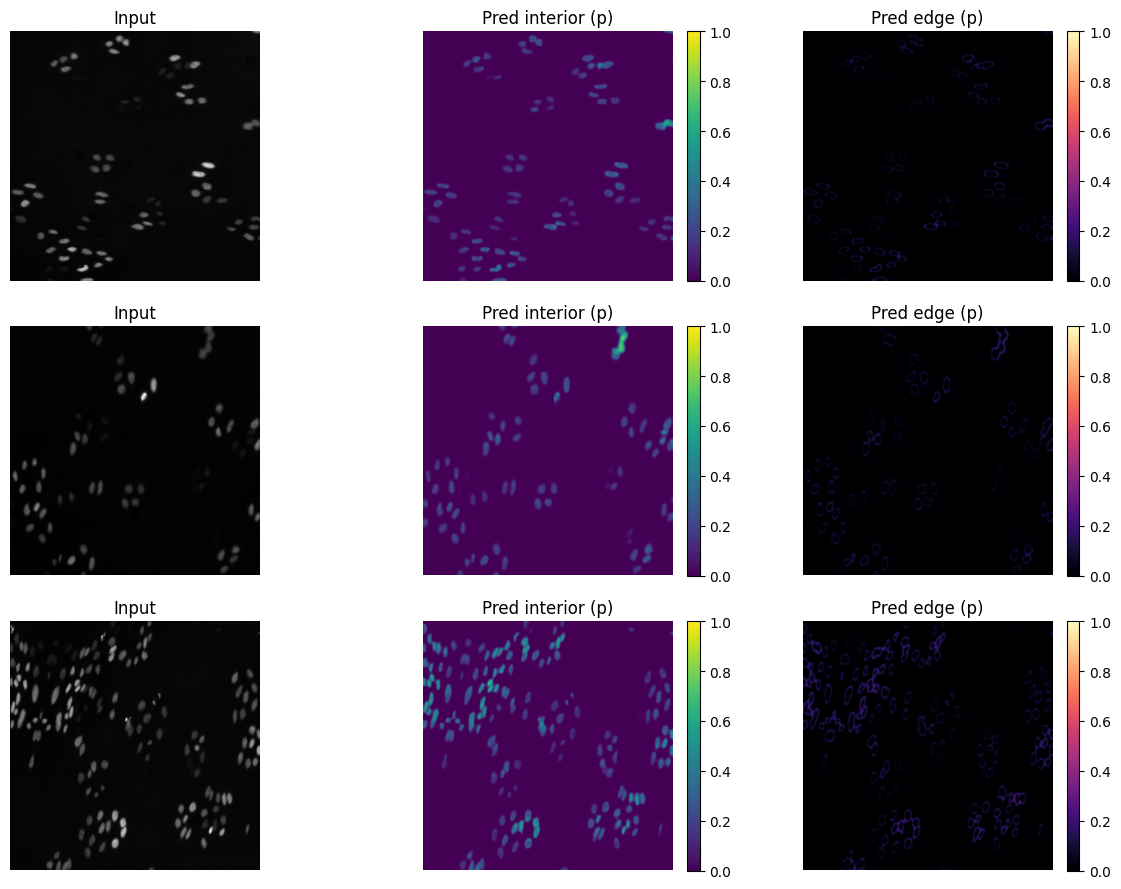

In [87]:
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=50,
    patience=10,
)
print(run_info)

show_predictions(model, train_loader, DEVICE, num_samples=3)

# Save results

In [89]:
from pathlib import Path
import numpy as np
import torch
import tifffile as tiff

# 1) Load checkpoint (prefer last, fallback to best)
ckpt_dir = PROJECT_ROOT / "checkpoints" / "resnet18_pure_torch"
last_ckpt = ckpt_dir / "last_model.pth"
best_ckpt = ckpt_dir / "best_model.pth"

if last_ckpt.exists():
    ckpt_path = last_ckpt
elif best_ckpt.exists():
    ckpt_path = best_ckpt
else:
    raise FileNotFoundError(
        f"No checkpoint found in {ckpt_dir}. Expected one of: {last_ckpt.name}, {best_ckpt.name}"
    )

state_dict = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()
print(f"Loaded checkpoint: {ckpt_path}")

# 2) Build deterministic train inference dataset (no random aug)
train_infer_dataset = CellHeatmapDataset(train_img_paths, transform=val_tf)

# 3) Output folders
out_root = PROJECT_ROOT / "data" / "train_predictions"
pred_interior_dir = out_root / "pred" / "interior"
pred_edge_dir = out_root / "pred" / "edge"
mask_dir = out_root / "mask"

pred_interior_dir.mkdir(parents=True, exist_ok=True)
pred_edge_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)

# 4) Inference + save
with torch.no_grad():
    for idx in range(len(train_infer_dataset)):
        image, target, _gt_instance = train_infer_dataset[idx]   # <-- 3 items now
        stem = train_infer_dataset.pairs[idx][0].stem

        logits = model(image.unsqueeze(0).to(DEVICE))        # [1,2,H,W]
        probs = torch.sigmoid(logits)[0].cpu().numpy()       # [2,H,W]
        target_np = target.cpu().numpy()                     # [2,H,W]

        interior_pred = probs[0]
        edge_pred = probs[1]

        tiff.imwrite(pred_interior_dir / f"{stem}_interior_pred.tif", interior_pred.astype(np.float32))
        tiff.imwrite(pred_edge_dir / f"{stem}_edge_pred.tif", edge_pred.astype(np.float32))
        tiff.imwrite(mask_dir / f"{stem}_mask.tif", target_np.astype(np.float32))

print(f"Saved {len(train_infer_dataset)} interior predictions to: {pred_interior_dir}")
print(f"Saved {len(train_infer_dataset)} edge predictions to: {pred_edge_dir}")
print(f"Saved {len(train_infer_dataset)} mask files to: {mask_dir}")

Loaded checkpoint: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/last_model.pth
Saved 102 interior predictions to: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/data/train_predictions/pred/interior
Saved 102 edge predictions to: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/data/train_predictions/pred/edge
Saved 102 mask files to: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/data/train_predictions/mask


# MedSAM preparation

In [90]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tifffile as tiff

In [91]:
pred_root = PROJECT_ROOT / "data" / "train_predictions" / "pred"
interior_dir = pred_root / "interior"
edge_dir = pred_root / "edge"

prompts_dir = PROJECT_ROOT / "data" / "train_predictions" / "prompts"
prompts_dir.mkdir(parents=True, exist_ok=True)

assert interior_dir.exists(), f"Missing folder: {interior_dir}"
assert edge_dir.exists(), f"Missing folder: {edge_dir}"
assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"

In [92]:
def bump_local_maxima(interior_prob, min_peak=0.35, blur_ksize=5):
    """Return local maxima (y, x) from smoothed interior map."""
    if blur_ksize % 2 == 0:
        blur_ksize += 1

    smooth = cv2.GaussianBlur(
        interior_prob.astype(np.float32),
        (blur_ksize, blur_ksize),
        0
    )

    kernel = np.ones((3, 3), np.uint8)
    local_max = smooth == cv2.dilate(smooth, kernel)
    strong = smooth >= float(min_peak)
    peaks = np.logical_and(local_max, strong)

    ys, xs = np.where(peaks)
    scores = smooth[ys, xs] if len(xs) else np.array([], dtype=np.float32)
    return ys, xs, scores


def point_nms_xy(xs, ys, scores, radius=8):
    """Greedy NMS on points, keeping highest-score points first."""
    if len(xs) == 0:
        return []

    order = np.argsort(scores)[::-1]
    kept = []
    r2 = float(radius * radius)

    for idx in order:
        x = int(xs[idx])
        y = int(ys[idx])
        s = float(scores[idx])

        keep = True
        for p in kept:
            dx = x - p["x"]
            dy = y - p["y"]
            if dx * dx + dy * dy <= r2:
                keep = False
                break

        if keep:
            kept.append({"x": x, "y": y, "score": s})

    return kept


def generate_bump_prompts(interior_prob, edge_prob, max_pos=None, nms_radius=8, min_peak=0.35):
    """
    Positives: peaks in interior map.
    Negatives: strong edge points far from positives.
    """
    ys, xs, scores = bump_local_maxima(
        interior_prob,
        min_peak=min_peak,
        blur_ksize=5
    )
    pos = point_nms_xy(xs, ys, scores, radius=nms_radius)

    if max_pos is not None and max_pos > 0:
        pos = pos[:max_pos]

    edge_s = cv2.GaussianBlur(edge_prob.astype(np.float32), (3, 3), 0)
    ey, ex = np.where(edge_s >= 0.6)
    es = edge_s[ey, ex] if len(ex) else np.array([], dtype=np.float32)
    neg_cands = point_nms_xy(ex, ey, es, radius=max(8, nms_radius))

    neg = []
    min_r2 = float((max(10, nms_radius + 2)) ** 2)
    for p in neg_cands:
        far = True
        for q in pos:
            dx = p["x"] - q["x"]
            dy = p["y"] - q["y"]
            if dx * dx + dy * dy <= min_r2:
                far = False
                break
        if far:
            neg.append(p)

    max_neg = max(1, len(pos) // 3)
    neg = neg[:max_neg]

    return pos, neg


def rescale_points(points, sx, sy, w, h):
    """Map points from prediction space to original image space."""
    out = []
    for p in points:
        xo = int(np.clip(round(p["x"] * sx), 0, w - 1))
        yo = int(np.clip(round(p["y"] * sy), 0, h - 1))
        out.append({
            "x": xo,
            "y": yo,
            "score": float(p["score"]),
        })
    return out


def overlay_points(ax, img, pos, neg, title):
    ax.imshow(img, cmap="gray")
    if len(pos):
        ax.scatter(
            [p["x"] for p in pos],
            [p["y"] for p in pos],
            s=35,
            c="lime",
            marker="o",
            edgecolors="black",
            linewidths=0.6,
        )
    if len(neg):
        ax.scatter(
            [p["x"] for p in neg],
            [p["y"] for p in neg],
            s=35,
            c="red",
            marker="x",
            linewidths=1.0,
        )
    ax.set_title(title)
    ax.axis("off")


In [93]:
rows = []

stems = sorted([
    p.stem.replace("_interior_pred", "")
    for p in interior_dir.glob("*_interior_pred.tif")
])
assert len(stems) > 0, f"No prediction files found in {interior_dir}"

for stem in stems:
    interior_path = interior_dir / f"{stem}_interior_pred.tif"
    edge_path = edge_dir / f"{stem}_edge_pred.tif"
    img_path = IMGS_DIR / f"{stem}.tif"

    if not edge_path.exists() or not img_path.exists():
        continue

    interior_prob = tiff.imread(interior_path).astype(np.float32)
    edge_prob = tiff.imread(edge_path).astype(np.float32)
    img = tiff.imread(img_path).astype(np.float32)

    ph, pw = interior_prob.shape[-2], interior_prob.shape[-1]
    oh, ow = img.shape[-2], img.shape[-1]

    sx = float(ow) / float(pw)
    sy = float(oh) / float(ph)

    pos_pred, neg_pred = generate_bump_prompts(
        interior_prob=interior_prob,
        edge_prob=edge_prob,
        max_pos=None,     # set e.g. 64 if you want a prompt budget
        nms_radius=8,
        min_peak=0.35,
    )

    for p in pos_pred:
        rows.append({
            "image_stem": stem,
            "label": 1,
            "x_pred": int(p["x"]),
            "y_pred": int(p["y"]),
            "x_orig": int(np.clip(round(p["x"] * sx), 0, ow - 1)),
            "y_orig": int(np.clip(round(p["y"] * sy), 0, oh - 1)),
            "score": float(p["score"]),
            "method": "bump_maxima",
            "kind": "positive",
        })

    for p in neg_pred:
        rows.append({
            "image_stem": stem,
            "label": 0,
            "x_pred": int(p["x"]),
            "y_pred": int(p["y"]),
            "x_orig": int(np.clip(round(p["x"] * sx), 0, ow - 1)),
            "y_orig": int(np.clip(round(p["y"] * sy), 0, oh - 1)),
            "score": float(p["score"]),
            "method": "bump_maxima",
            "kind": "negative",
        })

prompts_df = pd.DataFrame(rows).sort_values(
    ["image_stem", "label", "score"],
    ascending=[True, False, False]
)

csv_path = prompts_dir / "medsam_prompts_train_bump.csv"
prompts_df.to_csv(csv_path, index=False)

print(f"Saved prompts: {csv_path} | total points: {len(prompts_df)}")
print("CSV contains both prediction-space and original-image-space coordinates.")

Saved prompts: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/data/train_predictions/prompts/medsam_prompts_train_bump.csv | total points: 5966
CSV contains both prediction-space and original-image-space coordinates.


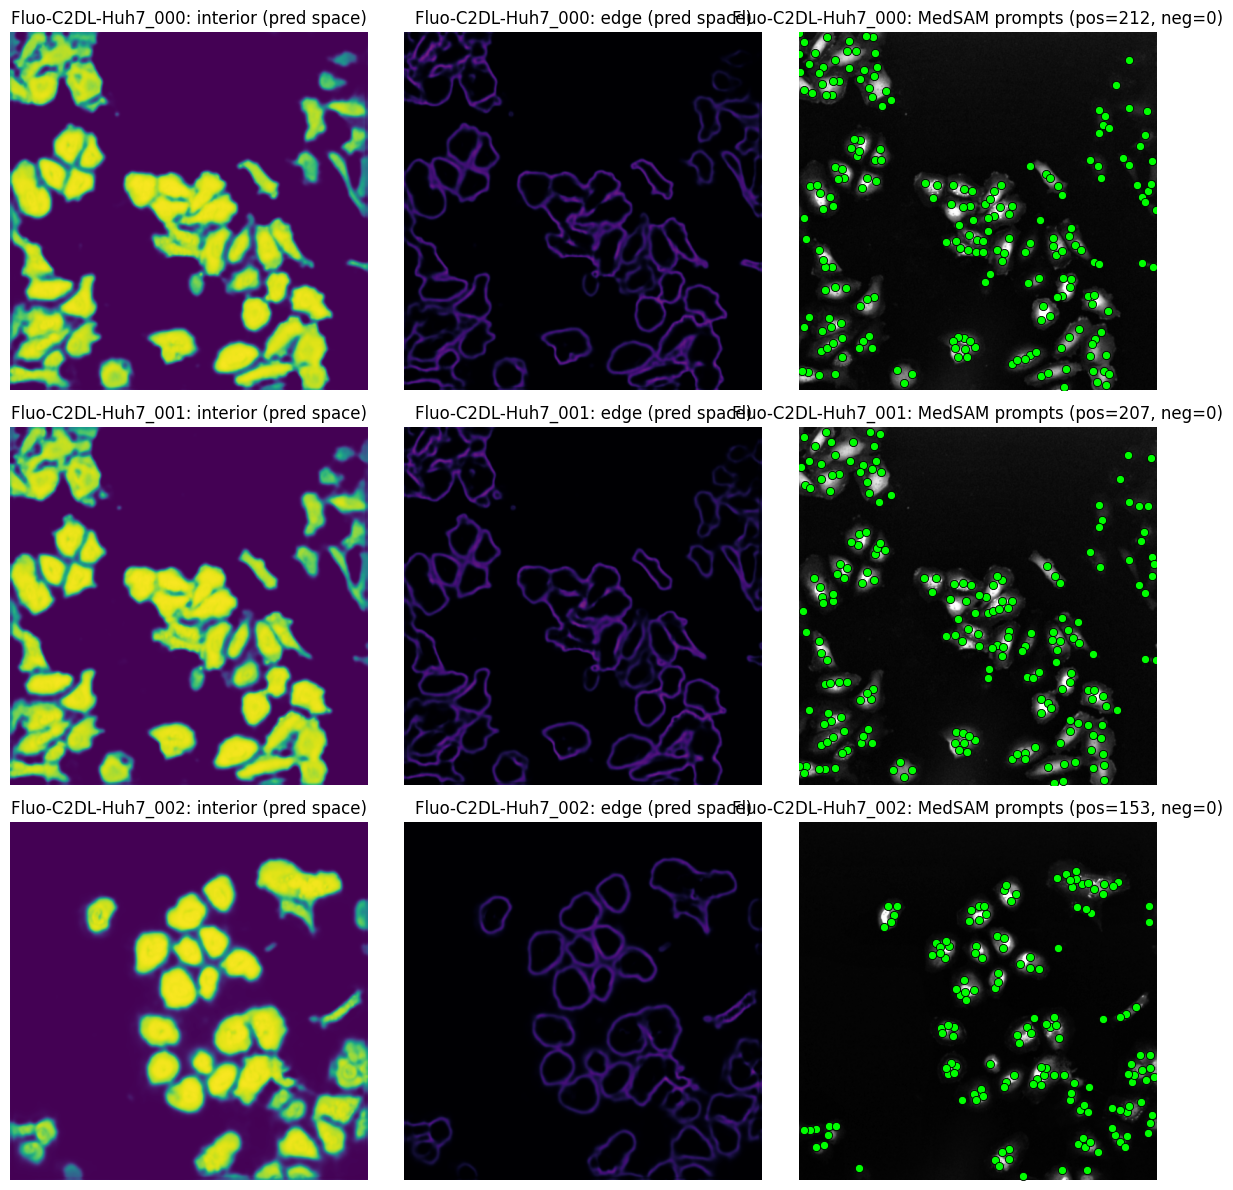

In [94]:
viz_stems = stems[:3]
fig, axes = plt.subplots(len(viz_stems), 3, figsize=(12, 4 * max(1, len(viz_stems))))
if len(viz_stems) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, stem in enumerate(viz_stems):
    img = normalize01(tiff.imread(IMGS_DIR / f"{stem}.tif").astype(np.float32))
    interior_prob = tiff.imread(interior_dir / f"{stem}_interior_pred.tif").astype(np.float32)
    edge_prob = tiff.imread(edge_dir / f"{stem}_edge_pred.tif").astype(np.float32)

    sub = prompts_df[prompts_df["image_stem"] == stem]

    pos = [
        {"x": int(v.x_orig), "y": int(v.y_orig)}
        for _, v in sub[sub["label"] == 1].iterrows()
    ]
    neg = [
        {"x": int(v.x_orig), "y": int(v.y_orig)}
        for _, v in sub[sub["label"] == 0].iterrows()
    ]

    axes[r, 0].imshow(interior_prob, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[r, 0].set_title(f"{stem}: interior (pred space)")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(edge_prob, cmap="magma", vmin=0.0, vmax=1.0)
    axes[r, 1].set_title(f"{stem}: edge (pred space)")
    axes[r, 1].axis("off")

    overlay_points(
        axes[r, 2],
        img,
        pos,
        neg,
        f"{stem}: MedSAM prompts (pos={len(pos)}, neg={len(neg)})"
    )

plt.tight_layout()
plt.show()